In [ ]:
# EJERCICIO DE PYTHON FOR DATA
# REALIZAMOS UN ANÁLISIS EXPLORATORIO DE LOS DATOS QUE VAMOS A CONTRAR EN LOS ARCHIVOS SUMINISTRADOS PARA EL EJERCICIO.
# LAS FASES DEL EJERCICIO SERÁN: 
#   0) IMPORTACIÓN DE DATOS. ENTENDIMIENTO DE LA ESTRUCTURA Y COMPOSICIÓN DE LOS DATOS 
#   1) TRANSFORMACIÓN Y LIMPIEZA.
#       1.1) Análisis de la Calidad de los Datos. Duplicados, Nulos, Vacíos, Indeterminados.
#       1.2) Trabajo con Duplicados y Nulos/Vacíos 
#       1.3) Corrección de Indeterminados. Merge y Concatenación. 
#   2) ANÁLSIS DESCRIPTIVO.
#       2.1) Analisis Univariante. Estadísticos. Visualización.
#       2.2) Análisis Bivariante y Correlaciones. Visualización.
#       2.3) Análisis Multivariante. Modelos de Regresión
#       2.4) Insights con cruce de Datos.


In [ ]:
# lo primero es importar todo el set de librerias necesarias.

import pandas as pd
import numpy as np
import openpyxl as xl
import psycopg2 as psy
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
###############################################################################################
###############                       0. IMPORTACION DE DATOS 
###############################################################################################

# Ahora leemos los datos
datos_banco = pd.read_csv('bank-additional.csv', index_col=0)
datos_customer = pd.read_excel('customer-details.xlsx',header=0)
# Activamos la reserva
datos_banco1=datos_banco
datos_customer1=datos_customer

In [ ]:
###############################################################################################
################# 0. ENTENDIMIENTO DE LA ESTRUCTURA Y COMPOSICIÓN DE LOS DATOS.
###############################################################################################

# Entendemos la estructura de datos y la composición de cada dataframe
# Empezamos por los datos bancarios
# Trabajamos con los distintos descriptores de campo
# print(datos_banco.head())
# print(datos_banco.tail())
# print(datos_banco.columns)
# print(datos_banco.info())

In [ ]:
# Continuamos por los detalles personales de cliente
# print(datos_customer.head())
# print(datos_customer.tail())
# print(datos_customer.shape)
# print(datos_customer.columns)
# print(datos_customer.info())
# print(datos_customer.describe())

In [ ]:
######################################################################
#####################  1. TRANSFORMACIÓN Y LIMPIEZA 
######################################################################
# 1.1 Análisis de la Calidad de los Datos. Duplicados, Nulos, Vacíos, Indeterminados.
#   PRIMERO ANALIZAMOS EL NÚMERO DE DATOS NULOS.
#   SEGUNDO ANALIZAMOS EL NÚMERO DE DATOS FALTANTES.
#   TERCERO ANALIZAMOS LOS DUPLICADOS.

In [ ]:
# vamos con el data frame de datos bancarios

In [ ]:
# datos_banco.isnull().sum()
# Según ésto, hay datos nulos en LOS DATOS de Edad, Educacion, Default, Housing, Loan y Euribor. 
# Resultado:
    #   age               5120
    #   job                345
    #   marital             85
    #   education         1807
    #   default           8981
    #   housing           1026
    #   loan              1026
    #   contact              0
    #   duration             0
    #   campaign             0
    #   pdays                0
    #   previous             0
    #   poutcome             0
    #   emp.var.rate         0
    #   cons.price.idx     471
    #   cons.conf.idx        0
    #   euribor3m         9256
    #   nr.employed          0
    #   y                    0
    #   date               248
    #   latitude             0
    #   longitude            0
    #   id_                  0


In [ ]:
# datos_banco.isna().sum()
# Según ésto y aunqeu son conceptos distintos, los datos Faltantes son coincidentes con los datos Nulos, por lo que vamos a trabajar bajo un concepto único.
# Resultados
    # age               5120
    # job                345
    # marital             85
    # education         1807
    # default           8981
    # housing           1026
    # loan              1026
    # contact              0
    # duration             0
    # campaign             0
    # pdays                0
    # previous             0
    # poutcome             0
    # emp.var.rate         0
    # cons.price.idx     471
    # cons.conf.idx        0
    # euribor3m         9256
    # nr.employed          0
    # y                    0
    # date               248
    # latitude             0
    # longitude            0
    # id_                  0
    # dtype: int64

In [ ]:
# datos_banco.duplicated()
# Según ésto, no hay datos duplicados. Ahora vamos a ver si hay duplicados en el iD
# RESULTADOS
    # 0        False
    # 1        False
    # 2        False
    # 3        False
    # 4        False
    #          ...  
    # 19154    False
    # 26206    False
    # 15046    False
    # 15280    False
    # 27570    False
    # Length: 43000, dtype: bool
    # datos_banco['ID'].duplicated()
    # 0        False
    # 1        False
    # 2        False
    # 3        False
    # 4        False
    #          ...  
    # 42995    False
    # 42996    False
    # 42997    False
    # 42998    False
    # 42999    False
    # Name: ID, Length: 43000, dtype: bool
    # Según ésto, no hay duplicados en el id.

In [ ]:
# Ahora vamos con el data frame de datos personales de cliente

In [ ]:
# datos_customer.isnull().sum()
# Según ésto, no hay datos nulos.
# RESULTADOS
    # Unnamed: 0           0
    # Income               0
    # Kidhome              0
    # Teenhome             0
    # Dt_Customer          0
    # NumWebVisitsMonth    0
    # ID                   0
    # dtype: int64

In [ ]:
# datos_customer.isna().sum()
# Según ésto, tampoco hay datos faltantes.
# RESULTADOS
    # Unnamed: 0           0
    # Income               0
    # Kidhome              0
    # Teenhome             0
    # Dt_Customer          0
    # NumWebVisitsMonth    0
    # ID                   0
    # dtype: int64

In [ ]:
# datos_customer.duplicated().sum()
#Según ésto significa que no hay duplicados en las filas. Pero vamos a comprobar para todas las columnas-.
# RESULTADOS
    # 0

In [ ]:
# datos_customer.duplicated(subset=['Income','Kidhome','Teenhome','Dt_Customer']).sum()
# resultados
    # 0
# Según ésto tampoco hay ducplicados en las columnas clave. pero y en el ID?
# datos_customer['ID'].duplicated().sum()
# resultados
#Según ésto tampoco hay duplicados en el ID

In [ ]:
########################################################################
########################### 1.2 TRABAJO CON DUPLICADOS Y NULOS/VACÍOS.
########################################################################
###########################  CAMPO A CAMPO: AGE

# datos_banco.isnull().sum()
# Según ésto, hay datos nulos en lso registros de Edad, Educacion, Default, Housing, Loan y Euribor. 
# Resultado:
#   age               5120
#   job                345
#   marital             85
#   education         1807
#   default           8981
#   housing           1026
#   loan              1026
#   cons.price.idx     471
#   euribor3m         9256
#   date               248
#   ......
#   Vamos a trabajar uno a uno.

In [ ]:
datos_banco['age'].value_counts()
# Resultado 
# age
# 38.0    2423
# 32.0    2288
# 31.0    2128
# 33.0    1855
# 39.0    1818
# 36.0    1789
# 37.0    1738
# 34.0    1677
# 35.0    1658
# 30.0    1620
# Name: count, dtype: int64


In [ ]:
#Sustituimos los blancos de 'edad' por la mediana de la edad (más frecuente) entre los grupos similares de trabajo, situación civil y educación.
datos_banco['age']=datos_banco['age'].fillna(datos_banco.groupby(['job','marital','education'])['age'].transform('median'))
# Comprobamos
datos_banco.isnull().sum().head(10)
# Resultado 
# age           302
# job           345
# marital        85
# education    1807
# default      8981
# housing      1026
# loan         1026
# contact         0
# duration        0
# campaign        0
# dtype: int64

In [ ]:
# y ahora sustituimos las edades que faltan por la mediana completa de todo el archivo
# Rellenar los que siguen siendo NaN
datos_banco['age'] = datos_banco['age'].fillna(datos_banco['age'].median())
# ahora comprobamos que todos los registros del data frame tienen la edad cumplimentada.
datos_banco.isnull().sum()
# Resultado
# age           0
# job           345
# marital        85
# education    1807
# default      8981
# housing      1026
# .....

In [ ]:
###########################  CAMPO A CAMPO: JOB
# Vamos a trabajar con la job utilizando el método unique. Devuelve un array de srings
datos_banco ['job'].unique()
# Resultado
# StringArray>
# [    'housemaid',      'services',        'admin.',   'blue-collar',
#    'technician',       'retired',    'management',    'unemployed',
#  'self-employed',             nan,  'entrepreneur',       'student']
# Length: 12, dtype: str

In [ ]:
# Vamos a sustituir los NaN/vacíos por valores de 'Undetermined'
# UTILIZAMOS EL MÉTODO LAMBDA PARA SUSTITUIR LOS VALORES DE LA COLUMNA 'JOB' QUE ESTÁN EN BLANCO O VACÍOS POR 'UNDETERMINED'
datos_banco['job']=datos_banco['job'].apply(lambda x: 'Undetermined' if pd.isna(x) else x)
# Comprobamos
datos_banco ['job'].value_counts()
# Resultado
# admin.           10873
#blue-collar       9654
# technician        7026
# services          4162
# management        3050
# retired           1790
# ........
# student            903
# ----->>>> Undetermined       345
# Name: count, dtype: int64
#

In [ ]:
###########################  CAMPO A CAMPO: MARITAL
# Vamos a cumplmentar con 'Undetermined' aquellos valores de la columna 'Marital'
datos_banco ['marital'].unique()
# Resultado
#      <StringArray>
#      ['MARRIED', 'SINGLE', 'DIVORCED', 'NAN']
#      Length: 4, dtype: str

In [ ]:
# Vamos a cumplmentar con 'Undetermined' aquellos valores de la columna 'Marital' que están blancos o vacíos.
# UTILIZAMOS EL MÉTODO LAMBDA PARA SUSTITUIR LOS VALORES DE LA COLUMNA 'MARITAL' QUE ESTÁN EN BLANCO O VACÍOS POR 'UNDETERMINED'
datos_banco['marital']=datos_banco['marital'].apply(lambda x: 'Undetermined' if pd.isna(x) else x)
# comprobamos 
datos_banco ['marital'].unique()
# Resultado
#      <StringArray>
#      ['MARRIED', 'SINGLE', 'DIVORCED', 'Undetermined']

In [ ]:
###########################  CAMPO A CAMPO: EDUCATION
#Revisamos los valores de 'education' utilizando el Unique. Si se utiliza el count(*) no salen los NaN
datos_banco ['education'].unique()
# Resultado
# StringArray>
#[           'basic.4y',         'high.school',            'basic.6y',
#            'basic.9y', 'professional.course',                   nan,
#   'university.degree',          'illiterate']
# Length: 8, dtype: str

In [ ]:
# UTILIZAMOS EL MÉTODO LAMBDA PARA SUSTITUIR LOS VALORES DE LA COLUMNA 'EDUCATION' QUE ESTÁN EN BLANCO O VACÍOS POR 'UNDETERMINED'
datos_banco['education']=datos_banco['education'].apply(lambda x: 'Undetermined' if pd.isna(x) else x)
datos_banco ['education'].unique()
# Resultado
# [           'basic.4y',         'high.school',            'basic.6y',
#            'basic.9y', 'professional.course',        'Undetermined',
#   'university.degree',          'illiterate']
#Length: 8, dtype: str

In [ ]:
###########################  CAMPO A CAMPO: DEFAULT
# Vamos con la morosidad. Inclumpimiento de pagos.
datos_banco ['default'].value_counts()
# Resultado
# default
# 0.0    42997
# 1.0        3
#Name: count, dtype: int64
# Hemos de suponer que aquellos que no son NaN es porque no consta incumplimiento, con lo que los vamos a cumplimentar como 0.0, que son la gran mayoría.

In [ ]:
# Utilizamos el método lambda para sustituir los valores de la columna 'default' que están en blanco o vacíos por 0.0
datos_banco['default']=datos_banco['default'].apply(lambda x: 0.0 if pd.isna(x) else x)
datos_banco ['default'].value_counts()
# Resultado
# default
# 0.0    42997
# 1.0        3
# Name: count, dtype: int64

In [ ]:
###########################  CAMPO A CAMPO: LOAN & HOUSING
# Vamos con Housing y Loan. 
# datos_banco['housing'].value_counts()
# datos_banco ['housing'].unique()
# datos_banco ['loan'].unique()
# BUSCAMOS LAS DISTINTAS COMBINACIONES DE HOUSING Y LOAN PARA VER SI LOS NULOS/NA/BLANCOS SE CONCENTRAN EN ALGUNA DE LAS COMBINACIONES.
resultado = datos_banco[(datos_banco['housing']==0.0) & (datos_banco['loan']==0.0)]
# repetimos para todas las 4 combinaciones de 1's y 0's
len(resultado)
# Hay 3846 registros con housing y loan ==1 ambos
# Hay 18652 registros con housing =1 y loan = 0
# Hay 2686 registros con housing =0 y loan = 1
# Hay 16790 registros con housing =0 y loan = 0

# El resto hasta 43.000 son 'NaN'. +43000-3846-18652-2686-16790, que salen justo los 1026 del analisis


In [ ]:
# Ahora usamos una función lambda para sustituir los nulos por valor -1 (que significará indeterminado hasta más adelante)
datos_banco['housing']=datos_banco['housing'].apply(lambda x: -1 if pd.isna(x) else x)
datos_banco['loan']=datos_banco['loan'].apply(lambda x: -1 if pd.isna(x) else x)
# COMPROBAMOS
datos_banco['housing'].value_counts()
# Resultado
# housing
# 1.0    22498
# 0.0    19476
# -1.0     1026
datos_banco['loan'].value_counts()
# loan
# 0.0    35442
# 1.0     6532
#-1.0     1026
# Name: count, dtype: int64


In [ ]:
###########################  CAMPO A CAMPO: LOAN & HOUSING
# Vamos a rellenar los blancos de 'cons.price.idx' con las medias de los valores de esa columna agrupadas por 'cons.conf.idx' que no tiene blancos.
# primero vamos a ver los valores distintos de cons.conf.idx
datos_banco['cons.conf.idx'].value_counts()
# Resultado
# cons.conf.idx
# -42,7    7004
# -46,2    6057
# -36,1    5408
# -41,8    4568
# -42      3782
# .....
# -47,1    2581

In [ ]:
###########################  CAMPO A CAMPO: INDICE DE PRECIOS AL CONSUMO
# ahora vamos a ver los valores de indice de precios al consumo cons.price.idx
datos_banco['cons.price.idx'].unique()
# Resultado
# <StringArray>
# ['93,994',      nan, '94,465', '93,918', '93,444', '93,798',   '93,2',
#  '92,756', '92,843', '93,075', '92,893', '92,963', '92,469', '92,201',
# '92,379', '92,431', '92,649', '92,713', '93,369', '93,749', '93,876',
# '94,055', '94,215', '94,027', '94,199', '94,601', '94,767']
# Length: 27, dtype: str
# vamos a contar cuantos blancos hay
datos_banco['cons.price.idx'].isna().sum()
# Resultado
# np.int64(471)
# hay 471 valores blancos. 


In [ ]:
# quiero los valores distintos de cons.price agrupados por los valores de cons.conf.
datos_banco.groupby('cons.conf.idx')['cons.price.idx'].unique()
# Resultado
# cons.conf.idx
# -26,9    [92,431, nan]
# -29,8    [92,379, nan]
# -30,1    [92,649, nan]
# -31,4    [92,201, nan]
# -33      [92,713, nan]
# -33,6    [92,469, nan]
# -34,6    [93,749, nan]
# .......

In [ ]:
# Ahora utilziamos los valores anteriores para rellenar los blancos. 
# utilizamos el método lambda para rellenar los blancos de 'cons.price.idx' con la moda de los valores de esa columna agrupadas por 'cons.conf.idx' que no tiene blancos.
datos_banco['cons.price.idx']= datos_banco['cons.price.idx'].fillna(datos_banco.groupby('cons.conf.idx')['cons.price.idx'].transform(lambda x: x.mode()[0] if not x.mode().empty else None))

In [ ]:
# validamos
# datos_banco.isnull().sum()
# Resultado
# age                  0
# job                  0
# marital              0
# emp.var.rate         0
# ....
# cons.price.idx       0
# cons.conf.idx        0

In [ ]:
###########################  CAMPO A CAMPO: EURIBOR A 3 MESES
# Vamos con el Euribor. Es un string
datos_banco['euribor3m'].unique()
# resultado
# <StringArray>
# ['4,857',     nan, '4,856', '4,855', '4,859',  '4,86', '4,858', '4,864',
# '4,865', '4,866',
# ...
#  '1,05', '1,049', '1,046', '1,041',  '1,04', '1,039', '1,035',  '1,03',
# '1,031', '1,028']
# Length: 310, dtype: str

In [ ]:
#quiero ver si el valor del euribor tiene alguna correlación con la fecha. Para ello, vamos a contar las combinaciones de valores de euribor3m y date.
datos_banco[['euribor3m','date']].value_counts().head(25)
# resultado
# euribor3m  date              
# 4,857      30-septiembre-2017    9
# 4,961      28-febrero-2015       9
# 4,857      28-febrero-2018       8
# 4,962      30-septiembre-2017    8
# 4,857      28-febrero-2019       7
#            29-diciembre-2018     6
#            28-febrero-2016       6
#            30-abril-2015         6
# 4,961      30-abril-2016         6
# 4,962      28-agosto-2016        6
#            28-febrero-2016       6
#            30-septiembre-2015    6
# ....
# 4,961      27-mayo-2018          5
# 4,959      28-febrero-2016       5

In [ ]:
# Ahora utilziamos los valores del euribor más frecuente en las fechas iguales para rellenar los blancos. 
# utilizamos el método lambda para rellenar los blancos de 'euribor3m' con la moda de los valores de esa columna agrupadas por 'date' que no tiene blancos.
datos_banco['euribor3m']= datos_banco['euribor3m'].fillna(datos_banco.groupby('nr.employed')['euribor3m'].transform(lambda x: x.mode()[0] if not x.mode().empty else None))

In [ ]:
# Cruzando los datos de ambas columnas, se demuestra qeu existe una elevada correlación entre el número de empleados y determinados indices euribor en escala más altas o más bajas. 
datos_banco=datos_banco.reset_index(drop=True)
# revisamos las combinaciones de valores de euribor3m y nr.employed mediante un crosstab
pd.crosstab(datos_banco['euribor3m'],datos_banco['nr.employed']).head(50)
# resultados
# nr.employed	4963,6	4991,6	5008,7	5017,5	5023,5	5076,2	5099,1	5176,3	5191	5195,8	5228,1
# euribor3m											
# 0,634	0	0	8	0	0	0	0	0	0	0	0
# 0,635	0	0	37	0	0	0	0	0	0	0	0
# 0,636	0	0	10	0	0	0	0	0	0	0	0
# 0,637	0	0	6	0	0	0	0	0	0	0	0
# .....

In [ ]:
###########################  CAMPO A CAMPO: nr.employed
# Vamos a rellenar los blancos de 'nr.employed' 
# primero vamos a ver los valores distintos de nr.employed 
datos_banco['nr.employed'].unique()
# resultado. No hay NaN
# <StringArray>
# [  '5191', '5228,1', '5195,8', '5176,3', '5099,1', '5076,2', '5017,5',
#  '5023,5', '5008,7', '4991,6', '4963,6']
# ahora vamos a ver que no hay nulos en nr.employed
# datos_banco['nr.employed'].isna().sum()
# datos_banco['nr.employed'].isnull().sum()
# resultado
# np.int64(0)

In [ ]:
###########################  CAMPO A CAMPO: DATE
# datos_banco['date'].isnull().sum()
# resultado
# np.int64(248)
#El campo date es un string. Vemos que tiene 248 nulos.
#vamos a trabajarlo de momento asignando un valor de 'Undated' a los valores nulos.
# Vamos a cumplmentar con 'Undated' aquellos valores de la columna 'fecha' que están blancos o vacíos.
# Utilizamos el método lambda para sustituir los valores de la columna 'date' que están en blanco o vacíos por 'Undated'
datos_banco['date']=datos_banco['date'].apply(lambda x: 'Undated' if pd.isna(x) else x)
# comprobamos 
datos_banco ['date'].value_counts()
# resultado
# date
# Undated              248
# 28-febrero-2018       95
# 28-febrero-2016       94
# 28-febrero-2015       92
# 28-febrero-2017       89
# ......

In [ ]:
#Tenemos que convetir las fechas 'date' en un formato legible de fecha DateTime.
meses = {"enero": "01", "febrero": "02", "marzo": "03",
    "abril": "04", "mayo": "05", "junio": "06",
    "julio": "07", "agosto": "08", "septiembre": "09",
    "octubre": "10", "noviembre": "11", "diciembre": "12"}

def convertir_fecha(fecha):
    try:
        dia, mes, año = fecha.lower().split("-")
        mes_num = meses[mes]
        return f"{año}-{mes_num}-{dia}"
    except:
        return None

datos_banco['date'] = datos_banco['date'].apply(convertir_fecha)
datos_banco['date'] = pd.to_datetime(datos_banco['date'], errors='coerce')

# Comprobamos que se han convertido las fechas
datos_banco['date'].head(10)

In [ ]:
###########################  CAMPO A CAMPO: CONTACT
# vamos a ver los valores distintos de contact y contarlos
# datos_banco['contact'].unique()
# datos_banco['contact'].value_counts()
# datos_banco['contact'].isnull().sum()
# datos_banco['contact'].isna().sum()
# type(datos_banco['contact'].iloc[0])
# resultado. No hay nulos, ni blancos, no NaN. Es un STR.
# resultado
# contact
# cellular     27396
# telephone    15604

In [ ]:
###########################  CAMPO A CAMPO: duration
# vamos a ver los valores distintos de duration
# datos_banco['duration'].unique()
# datos_banco['duration'].value_counts()
# datos_banco['duration'].isnull().sum()
# datos_banco['duration'].isna().sum()
# type(datos_banco['duration'].iloc[0])
# resultado. No hay nulos, ni blancos, no NaN. Es un int.


In [ ]:
###########################  CAMPO A CAMPO: campaign
# vamos a ver los valores distintos de campaign
# datos_banco['campaign'].unique()
# datos_banco['campaign'].value_counts()
# datos_banco['campaign'].isnull().sum()
# datos_banco['campaign'].isna().sum()
# type(datos_banco['campaign'].iloc[0])
# resultado. No hay nulos, ni blancos, no NaN. Es un int.

In [ ]:
###########################  CAMPO A CAMPO: PDAYS
# vamos a ver los valores distintos de pdays
# datos_banco['pdays'].unique()
# datos_banco['pdays'].value_counts()
# datos_banco['pdays'].isnull().sum()
# datos_banco['pdays'].isna().sum()
# type(datos_banco['pdays'].iloc[0])
# resultado. No hay nulos, ni blancos, no NaN. Es un int.

In [ ]:
###########################  CAMPO A CAMPO: PREVIOUS
# vamos a ver los valores distintos de previous
# datos_banco['previous'].unique()
# datos_banco['previous'].value_counts()
# datos_banco['previous'].isnull().sum()
# datos_banco['previous'].isna().sum()
# type(datos_banco['previous'].iloc[0])
# resultado. No hay nulos, ni blancos, no NaN. Es un int.

In [ ]:
###############################################################################
##################   1.3) Corrección de Indeterminados. Merge y Concatenación. 
###############################################################################
# AHORA VAMOS A CONCATENER LOS 2 DATA FRAME EN UN NUEVO DATA FRAME
# VALORAMOS QUE LA CORRECCIÓN DE INDETERMINADOS SE HACE mejor CON LA ASIGNACIÓN con LOS DATOS DE AMBOS DATAFRAME, DE FORMA COMBINADA.
datos_banco['id_'].dtype
# lO PRIMERO ES ASIGNAR EL TIPO DE DATO STRING A LOS CAMPOS DE ID DE AMBOS DATA FRAME PARA PODER HACER UN MERGE POSTERIOR. VAMOS A UTILZIAR ESTOS CAMPOS COMO INDICE PARA HACER EL MERGE.
# Resultado
# <StringDtype(storage='python', na_value=nan)>
datos_customer['ID'].dtype
# Resultado
# <StringDtype(storage='python', na_value=nan)>

In [ ]:
######################### MERGE Y CONCATENACIÓN. 
#Lo primero de todo es renombrar la columna de Datos_banco como la de Datos_customer.
datos_banco = datos_banco.rename(columns={'id_': 'ID'})
#comprobamos
# datos_banco.info()
#ahora creamos el data frame consolidado, incorporando la información de Customer a la de datos banco.
datos_consolidado = pd.merge(datos_banco, datos_customer, on='ID', how='left')
# comprobamos
# datos_consolidado.info()
# resultado
# <class 'pandas.core.frame.DataFrame'>

In [ ]:
#vamos a comprobar la calidad del merge. 
#primero contamos el nº de ID's distintos en datos_banco. - 43000
datos_banco.index.nunique()
#segundo contamos el nº de ID's distintos en datos_customers -20115
datos_customer.index.nunique()
#tercero comprobamos el nº de ID's distintos en datos_consolidado - 43.000. Está claro que ha hecho un Join - Left.
datos_consolidado.index.nunique()
# Resultados 
# datos_banco.index.nunique()        43000
# datos_customer.index.nunique()     20115
# datos_consolidado.index.nunique() 43000

In [ ]:
datos_consolidado.index.duplicated().sum()
# Resultados
# datos_consolidado.index.duplicated().sum()     0


In [ ]:
# comprobamos calidad de indices en ambos data frame
indices_no_en_banco = datos_customer.index.difference(datos_banco.index)
print(indices_no_en_banco)
# Resultados
# RangeIndex(start=0, stop=0, step=1). Esto quiere decir que no hay indices en customers fuera de datos_banco, lo que ayuda a aclarar el panorama. 

In [ ]:
#######################################################
######################### CORRECCIÓN DE INDETERMINADOS.
# ##################################################### 
# CAMPO A CAMPO: ASIGNACIÓN DE VALORES A LOS CAMPOS DE STRING QUE HEMOS DEJADO COMO 'Undetermined' EN LOS CAMPOS DE JOB, MARITAL Y EDUCATION.
# Vamos a revisar los valores de los campos de string que hemos dejado como 'Undetermined' para ver si podemos asignarles un valor más concreto.
# ahora vamos a resolver los valores Undetermined de los campos de string. 
# datos_consolidado.groupby(['job','marital','education','age']).size()
# resultado
# job         marital   education          age 
# admin.      DIVORCED  basic.4y           48.0    1
#                                          50.0    2
#                                         59.0    1
#                      basic.6y           30.0    1
#                                         34.0    1
#....

In [ ]:
# Borramos la columna Unnamed:0
# datos_consolidado = datos_consolidado.drop('Unnamed: 0', axis=1)
# comprobamos
# datos_consolidado.info()

In [ ]:
# CAMPO A CAMPO: INCOME. Los ingresos son un campo imporante que pueden explicar bastante del comportamiento del cliente.
# ANalizamos la distribución de ingresos por trabajo y educación
datos_consolidado.groupby(['job','education'])['Income'].describe().head(20)
# Resultados
# job         education          count      mean        std     min       25%       50%       75%       max
# Undetermined	Undetermined	88.0	94587.863636	50660.726958	9585.0	48387.00	95477.5	141491.50	173323.0
# basic.4y	30.0	103193.833333	46246.472345	10610.0	68055.50	113956.0	141826.50	169974.0
# basic.6y	20.0	99621.450000	55795.986846	15754.0	46379.75	111532.0	140655.50	177115.0
# basic.9y	23.0	103779.869565	52830.740920	10857.0	65226.50	110818.0	145070.50	179404.0
# high.school	25.0	95196.760000	50138.858490	6186.0	59963.00	88773.0	140218.00	176606.0
#...
# TENEMOS QUE RESOLVER EL VALOR DE INGRESOS DE LOS 88 REGISTROS QUE TIENEN UNDETERMINED EN EDUCACIÓN Y TRABAJO.

In [ ]:
# RELLENAMOS LOS VALORES NULOS DE INGRESOS DE LOS 88 REGISTROS QUE TIENEN UNDETERMINED EN EDUCACIÓN Y TRABAJO CON LA MEDIA DE INGRESOS DE LOS REGISTROS QUE TIENEN EL MISMO NIVEL DE EDUCACIÓN Y TRABAJO, PERO SIN VALORES INDETERMINADOS.
datos_consolidado['Income'] = datos_consolidado['Income'].fillna(datos_consolidado.groupby(['job','education'])['Income'].transform('mean'))
# COMPROBAMOS
datos_consolidado.groupby(['job','education']).size().head(50)
# Resultados
# job           education          
# Undetermined  Undetermined            135
#               basic.4y                 55
#              basic.6y                 23
#              basic.9y                 33
#              high.school              38
#              professional.course      13
#              university.degree        48
#admin.        Undetermined            258
#              basic.4y                 80
#              basic.6y                154
#......

In [ ]:
# aun quedan algunos registros con valores nulos en ingresos. Vamos a rellenarlos con la media de ingresos de todo el data frame.
datos_consolidado[datos_consolidado['Income'].isnull()]

In [ ]:
# Vamos a asignar la media global
datos_consolidado['Income'] = datos_consolidado['Income'].fillna(datos_consolidado['Income'].mean())
# comprobamos que ya no hay registros con ingresos nulos.
datos_consolidado[datos_consolidado['Income'].isnull()]
# resultados 
# age	job	marital	education	default	housing	loan	contact	duration	campaign	...	Dt_Customer	NumWebVisitsMonth
# 0 rows × 29 columns

In [ ]:
###########################  CAMPO A CAMPO: Kidhome
# vamos a ver los valores distintos de Kidhome
# datos_consolidado['Kidhome'].unique()
# datos_consolidado['Kidhome'].value_counts()
# datos_consolidado['Kidhome'].isnull().sum()
# datos_consolidado['Kidhome'].isna().sum()
# Ojo, hay 22982 NaN, pero no hay nulos ni blancos. Es decir, el valor de NaN puede ser valor válido que significa que no tiene hijos?.
# type(datos_consolidado['Kidhome'].iloc[0])
# resultado. No hay nulos, ni blancos, pero hay NaN. Es un float.

In [ ]:
#Ahora vamos a rellenar los valores nulos de Kidhome con la mediana de los valores de esa columna agrupadas por edad y situación civil, que son las variables que más correlación tienen con el número de hijos.
datos_consolidado['Kidhome'] = datos_consolidado['Kidhome'].fillna(datos_consolidado.groupby(['age','marital'])['Kidhome'].transform('median'))
#Ahora comprobamos que ya no hay registros con Kidhome nulos.
datos_consolidado['Kidhome'] = datos_consolidado['Kidhome'].fillna(datos_consolidado['Kidhome'].median())
# comprobamos que ya no hay registros con Kidhome nulos.

In [ ]:
datos_consolidado['Kidhome'].value_counts()
# resultado
# Kidhome
# 1.0    29340
# 2.0     6813
# 0.0     6794
# 0.5       36
# 1.5       17

In [ ]:
###########################  CAMPO A CAMPO: Teenhome
# vamos a ver los valores distintos de Teenhome
# datos_consolidado['Teenhome'].unique()
# Resultado
# array([ 0.,  1.,  2., nan])
# datos_consolidado['Teenhome'].value_counts()
# datos_consolidado['Teenhome'].isnull().sum()
# datos_consolidado['Teenhome'].isna().sum()
# Ojo, hay 22982 NaN, pero no hay nulos ni blancos. Es decir, el valor de NaN puede ser valor válido que significa que no tiene hijos?.
# type(datos_consolidado['Teenhome'].iloc[0])
# resultado. No hay nulos, ni blancos, pero hay NaN. Es un float.

In [ ]:
# Vamos a rellenar los valores nulos de Teenhome con la mediana de los valores de esa columna agrupados por edad y estado civil, que son las variables que más correlación tienen con el número de hijos.
datos_consolidado['Teenhome'] = datos_consolidado['Kidhome'].fillna(datos_consolidado.groupby(['age','marital'])['Kidhome'].transform('median'))

# ahora vamos a rellenar los valores nulos de Kidhome con la mediana de los valores de esa columna, que es el valor más frecuente.
datos_consolidado['Teenhome'] = datos_consolidado['Kidhome'].fillna(datos_consolidado['Kidhome'].median())

# comprobamos que ya no hay registros con Kidhome nulos.

In [ ]:
datos_consolidado['Teenhome'].value_counts()
# resultado
# Teenhome
# 1.0    29340
# 2.0     6813
# 0.0     6794
# 0.5       36
# 1.5       17
# Observamos el hecho de los decimales en el número de hijos. Esto se debe a que hemos rellenado los valores nulos con la mediana, que es un valor decimal. 
# Esto no tiene sentido en el contexto de número de hijos, por lo que vamos a redondear los valores de Kidhome y Teenhome al número entero más cercano.
datos_consolidado['Kidhome'] = datos_consolidado['Kidhome'].round()
datos_consolidado['Teenhome'] = datos_consolidado['Teenhome'].round()
# validamos que ya no hay decimales en el número de hijos.
datos_consolidado['Kidhome'].value_counts()
# Resultado
# Kidhome
# 1.0    29340
# 0.0     6830
# 2.0     6830

In [ ]:
# ################## CAMPO A CAMPO: DT_CUSTOMER. MUY IMPORTANTE. 
# vamos a ver los valores distintos de dt_customer y cuantos hay
datos_consolidado['Dt_Customer'].value_counts().head(50)
# resultados
#       '2012-04-04 00:00:00',        '2012-12-30 00:00:00',
#        '2012-02-02 00:00:00',        '2012-12-21 00:00:00',
#        '2012-06-20 00:00:00',        '2012-01-24 00:00:00',
#        '2012-08-15 00:00:00',        '2012-12-10 00:00:00',
#        '2012-08-22 00:00:00',        '2012-02-09 00:00:00',
# ...
# '2012-06-20 18:46:57.391304', '2012-06-19 03:25:42.857142',
datos_consolidado['Dt_Customer'].isnull().sum()
# resultado
# np.int64(22982). hAY 22982 VALORES NULOS EN DT_CUSTOMER. HAY QUE RELLENARLOS CON UN VALOR DE FECHA, PERO ANTES HAY QUE ANALIZAR LOS VALORES DE ESA COLUMNA PARA VER SI SE PUEDE ASIGNAR UN VALOR DE FECHA MÁS CONCRETO A LOS REGISTROS QUE TIENEN EL VALOR NULO.
datos_consolidado['Dt_Customer'].isna().sum()
# resultado: np.int64(22982)

In [ ]:
# aHORA RELLENAMOS LOS VALORES NULOS DE Dt_Customer CON LA MEDIA DE LOS VALORES DE ESA COLUMNA AGRUPADOS POR CAMPAÑA QUE NO TIENE BLANCOS.
datos_consolidado['Dt_Customer'] = datos_consolidado['Dt_Customer'].fillna(datos_consolidado.groupby('campaign')['Dt_Customer'].transform('mean'))
# Rellenar los que queden
# Y AHORA RELLENAMOS LOS VALORES NULOS DE Dt_Customer CON LA MEDIA DE LOS VALORES DE ESA COLUMNA AGRUPADOS POR CAMPAÑA QUE NO TIENE BLANCOS.
datos_consolidado['Dt_Customer'] = datos_consolidado['Dt_Customer'].fillna(datos_consolidado['Dt_Customer'].mean())
# comprobamos que ya no hay registros con Dt_Customer nulos.
datos_consolidado['Dt_Customer'].isnull().sum()
# resultado: np.int64(0)
datos_consolidado['Dt_Customer'].isna().sum()
# resultado: np.int64(0)


In [ ]:
# ################## CAMPO A CAMPO: NumWebVisitsMonth. MUY IMPORTANTE. 
# vamos a ver los valores distintos de num_web_visits_month y cuantos hay
datos_consolidado['NumWebVisitsMonth'].value_counts().head(50)
# Nulos
datos_consolidado['NumWebVisitsMonth'].isnull().sum()
# resultado
# np.int64(22982). hAY 22982 VALORES NULOS EN NumWebVisitsMonth. HAY QUE RELLENARLOS CON UN VALOR DE NÚMERO DE VISITAS, PERO ANTES HAY QUE ANALIZAR LOS VALORES DE ESA COLUMNA PARA VER SI SE PUEDE ASIGNAR UN VALOR DE NÚMERO DE VISITAS MÁS CONCRETO A LOS REGISTROS QUE TIENEN EL VALOR NULO.


In [ ]:
# vamos a  rellenar los valores nulos de NumWebVisitsMonth con la media de los valores de esa columna agrupados por edad, trabajo, educación, contacto, duración y campaña, que son las variables que más correlación tienen con el número de visitas web al mes.
datos_consolidado['NumWebVisitsMonth'] = datos_consolidado['NumWebVisitsMonth'].fillna(datos_consolidado.groupby(['age','job','education','contact','duration','campaign'])['NumWebVisitsMonth'].transform('mean'))
# Rellenar los que queden
datos_consolidado['NumWebVisitsMonth'] = datos_consolidado['NumWebVisitsMonth'].fillna(datos_consolidado['NumWebVisitsMonth'].mean())
# comprobamos que ya no hay registros con NumWebVisitsMonth nulos.
datos_consolidado['NumWebVisitsMonth'].isnull().sum()

In [ ]:
# ######################### TRATAMIENTO DE INDETERMINADOS EN LOS CAMPOS DE STRING
# Hemos concluido la limpieza de los datos y el cumplmentado de nulos. Ahora vamos con los indeterminados.
print("job:", datos_consolidado['job'].unique())
print("marital:", datos_consolidado['marital'].unique())
print("education:", datos_consolidado['education'].unique())
print("default:", datos_consolidado['default'].unique())
print("housing:", datos_consolidado['housing'].unique())
print("loan:", datos_consolidado['loan'].unique())
print("campaign:", datos_consolidado['campaign'].unique())

# rESULTADO

# job: <StringArray>
# [    'housemaid',      'services',        'admin.',   'blue-collar',
#     'technician',       'retired',    'management',    'unemployed',
#  'self-employed',  'Undetermined',  'entrepreneur',       'student']
# Length: 12, dtype: str
# marital: <StringArray>
# ['MARRIED', 'SINGLE', 'DIVORCED', 'Undetermined']
# Length: 4, dtype: str
# education: <StringArray>
# [           'basic.4y',         'high.school',            'basic.6y',
#             'basic.9y', 'professional.course',        'Undetermined',
#    'university.degree',          'illiterate']
# Length: 8, dtype: str
# default: [0. 1.]
# housing: [ 0.  1. -1.]
# loan: [ 0.  1. -1.]
# campaign: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 19 18 23 14 22 25 16 17 15 20 56
#  39 35 42 28 26 27 32 21 24 29 31 30 41 37 40 33 34 43]


In [ ]:
# Imprimimos el número de registros que tienen el valor 'Undetermined' en los campos de string y el valor -1 en los campos de housing y loan.

num_ujobs = (datos_consolidado['job'] == 'Undetermined').sum()
print(f"Job Undetermined {num_ujobs}")
num_umarital = (datos_consolidado['marital'] == 'Undetermined').sum()
print(f"Marital Undetermined {num_umarital}")
num_ueducation = (datos_consolidado['education'] == 'Undetermined').sum()
print(f"Education Undetermined {num_ueducation}")
num_uhousing= (datos_consolidado['housing'] == -1).sum()
print(f"Housing Undetermined {num_uhousing}")
num_uloan= (datos_consolidado['loan'] == -1).sum()
print(f"Loan Undetermined {num_uloan}")

# Resultado
# Job Undetermined 345
# Marital Undetermined 85
# Education Undetermined 1807
# Housing Undetermined 1026
# Loan Undetermined 1026


In [ ]:
# Vamos a asignar los valores más frecuentes del resto de columnas cualitativas a los Undetermined de cada campo que contenga Undetermined. 
# que son Job, Marital, Education, Housing y Loan

# Paso 1: Imputación por grupo 
datos_consolidado['job'] = datos_consolidado['job'].mask(datos_consolidado['job'] == 'Undetermined', datos_consolidado.groupby(['marital','education','housing','loan'])['job'].transform(lambda x: x.mode()[0] if not x.mode().empty else 'Undetermined'))
datos_consolidado['marital'] = datos_consolidado['marital'].mask(datos_consolidado['marital'] == 'Undetermined', datos_consolidado.groupby(['job','education','housing','loan'])['marital'].transform(lambda x: x.mode()[0] if not x.mode().empty else 'Undetermined'))
datos_consolidado['education'] = datos_consolidado['education'].mask(datos_consolidado['education'] == 'Undetermined', datos_consolidado.groupby(['job','marital','housing','loan'])['education'].transform(lambda x: x.mode()[0] if not x.mode().empty else 'Undetermined'))
datos_consolidado['housing'] = datos_consolidado['housing'].mask(datos_consolidado['housing'] == -1, datos_consolidado.groupby(['job','marital','education','loan'])['housing'].transform(lambda x: x.mode()[0] if not x.mode().empty else -1))
datos_consolidado['loan'] = datos_consolidado['loan'].mask(datos_consolidado['loan'] == -1, datos_consolidado.groupby(['job','marital','education','housing'])['loan'].transform(lambda x: x.mode()[0] if not x.mode().empty else -1))

# Paso 2: Imputación global y cierre con 'Estimated'
job_global = datos_consolidado['job'].mode()[0]
datos_consolidado['job'] = datos_consolidado['job'].replace('Undetermined',f"{job_global} estimated")
marital_global = datos_consolidado['marital'].mode()[0]
datos_consolidado['marital'] = datos_consolidado['marital'].replace('Undetermined',f"{job_global} estimated")
education_global = datos_consolidado['education'].mode()[0]
datos_consolidado['education'] = datos_consolidado['education'].replace('Undetermined',f"{job_global} estimated")
housing_global = datos_consolidado['housing'].mode()[0]
datos_consolidado['housing'] = datos_consolidado['housing'].replace(-1,housing_global)
loan_global = datos_consolidado['loan'].mode()[0]
datos_consolidado['loan'] = datos_consolidado['loan'].replace(-1,loan_global)


In [ ]:
# Comprobamos. Ya no quedan nulos ni indeterminados. 

num_ujobs = (datos_consolidado['job'] == 'Undetermined').sum()
print(f"Job Undetermined {num_ujobs}")
num_umarital = (datos_consolidado['marital'] == 'Undetermined').sum()
print(f"Marital Undetermined {num_umarital}")
num_ueducation = (datos_consolidado['education'] == 'Undetermined').sum()
print(f"Education Undetermined {num_ueducation}")
num_uhousing= (datos_consolidado['housing'] == -1).sum()
print(f"Housing Undetermined {num_uhousing}")
num_uloan= (datos_consolidado['loan'] == -1).sum()
print(f"Loan Undetermined {num_uloan}")

# Resultado

# Job Undetermined 0
# Marital Undetermined 0
# Education Undetermined 0
# Housing Undetermined 0
# Loan Undetermined 0

In [ ]:
############# TRANSFORMACIÓN DE DATOS STRING QUE SON NÚMEROS EN NÚMEROS DE VERDAD (FLOAT)
# Vamos a transformar los datos string que son números en números de verdad (float), mediante una función.
def to_float(valor):
    try:
        # Convertir a string, reemplazar coma por punto y convertir a float
        return float(str(valor).replace(',', '.'))
    except:
        return np.nan 

In [ ]:
# CAMPO A CAMPO: cons.price.idx
#definimos una variable como una lista y la vamos rellenando con los valores numéricos
new_column = []
for valor in datos_consolidado['cons.price.idx']:
    new_value = to_float(valor)
    new_column.append(new_value)

# Asignamos al Data Frame
datos_consolidado['cons.price.idx']=new_column

# Comprobamos
datos_consolidado['cons.price.idx'].dtype

# Resultado
# dtype('float64')

In [ ]:
# Hacemos lo mismo con cons.conf.idx 
#definimos una variable como una lista y la vamos rellenando con los valores numéricos
new_column = []
for valor in datos_consolidado['cons.conf.idx']:
    new_value = to_float(valor)
    new_column.append(new_value)

# new_column
datos_consolidado['cons.conf.idx']=new_column
datos_consolidado['cons.conf.idx'].dtype

# Resultado
# dtype('float64')

In [ ]:
# Hacemos lo mismo con euribor3m 
#definimos una variable como una lista y la vamos rellenando con los valores numéricos
new_column = []
for valor in datos_consolidado['euribor3m']:
    new_value = to_float(valor)
    new_column.append(new_value)

datos_consolidado['euribor3m']=new_column
datos_consolidado['cons.conf.idx'].dtype

# Resultado
# dtype('float64')

In [ ]:
#################################################################################
###### ###################### 2)    EMPEZAMOS CON EL ANÁLISIS DESCRIPTIVO 
#################################################################################

In [ ]:
########################################################################################
############################ 2.1) ANÁLISIS UNI VARIANTE. ESTADÍSTICOS. VISUALIZACIÓN.
########################################################################################
############ Para ello vamos a analizar algunas variable por separado, para ver su distribución, su tendencia central, su dispersión, su forma, etc.
############ Vamos a crear data_frames parciales, 1) Analisis_datos_servicio y 2) Analisis_datos_mercado, 3) Analisis_datos_cliente
############ para analizar cada variable por separado 

In [ ]:
# Creamos Analisis_datos_servicio con las variables de servicio, que son las variables que tienen que ver con el servicio que disfruta el cliente.  
Analisis_datos_servicio = datos_consolidado[['ID','housing','loan','nr.employed','Dt_Customer','default','NumWebVisitsMonth','date','previous']].copy()
Analisis_datos_servicio.head(50)


In [ ]:
#Añadimos una columna de dias hasta la última interacción. 
Analisis_datos_servicio["dias_hasta_interaccion"] = (Analisis_datos_servicio["date"] - Analisis_datos_servicio["Dt_Customer"]).dt.days

In [ ]:
#Añadimos una columna de dias hasta hoy
hoy = pd.Timestamp.today()
Analisis_datos_servicio["dias_hasta_hoy"] = (hoy - Analisis_datos_servicio["Dt_Customer"]).dt.days

In [ ]:
# Creamos una columna que sea Dias sin contacto
Analisis_datos_servicio['dias_sin_contacto'] = (Analisis_datos_servicio['dias_hasta_hoy'] - Analisis_datos_servicio['dias_hasta_interaccion'])

In [ ]:
# Renombramos la columna date a date_ultima_interacción
Analisis_datos_servicio = Analisis_datos_servicio.rename(columns={'date': 'date_ultima_interaccion'})


In [ ]:
Analisis_datos_servicio.head(50)

In [ ]:
# Los principales estadísticos de las columnas numéricas, las modas de las columnas cualitativas y la distribución de frecuencias de las columnas cualitativas. 
# En el caso de las columnas de housing, loan las frecuencias de aparición de cada combinación de valores.
# En las columnas de fechas los máximo y los mínimos.

# Modas de las columnas cualitativas
print("Moda de housing:", Analisis_datos_servicio['housing'].mode()[0])
print("Moda de loan:", Analisis_datos_servicio['loan'].mode()[0])
# Distribución de frecuencias de las columnas cualitativas
print("Frecuencia de housing:\n", Analisis_datos_servicio['housing'].value_counts())
print("Frecuencia de loan:\n", Analisis_datos_servicio['loan'].value_counts())
# Frecuencia de combinaciones de housing y loan
print("Frecuencia de combinaciones de housing y loan:\n", Analisis_datos_servicio.groupby(['housing', 'loan']).size())
# Fechas máximas y mínimas
print("Fecha mínima de última interacción:", Analisis_datos_servicio['date_ultima_interaccion'].min())
print("Fecha máxima de última interacción:", Analisis_datos_servicio['date_ultima_interaccion'].max())
# imprimir el id del cliente más antiguo y su fecha de alta
cliente_mas_antiguo = Analisis_datos_servicio.loc[Analisis_datos_servicio['Dt_Customer'].idxmin()]
print("Cliente más antiguo ID:", cliente_mas_antiguo['ID']) 
print("Fecha de alta del cliente más antiguo:", cliente_mas_antiguo['Dt_Customer'])


In [ ]:
# ANalizamos con la función describe los principales estadísticos numéricos de los datos de servicios. Vemos que prácticamente no may outliers (min/max)
Analisis_datos_servicio.describe()
# Resultado 
# 	housing	loan	Dt_Customer	default	NumWebVisitsMonth	date_ultima_interaccion	previous	dias_hasta_interaccion	dias_hasta_hoy	dias_sin_contacto
# count	43000.000000	43000.000000	43000	43000.000000	43000.000000	42752	43000.000000	42752.000000	43000.000000	42752.000000
# mean	0.547070	0.151907	2012-07-01 13:19:00.835662	0.000070	16.532407	2017-07-01 19:55:11.676646	0.174023	1826.060138	5034.364000	3208.327166
# min	0.000000	0.000000	2012-01-01 00:00:00	0.000000	1.000000	2015-01-01 00:00:00	0.000000	739.000000	4852.000000	2296.000000
# 25%	0.000000	0.000000	2012-06-29 04:26:25.605319	0.000000	16.532407	2016-04-01 00:00:00	0.000000	1370.000000	5028.000000	2752.000000
# 50%	1.000000	0.000000	2012-07-01 18:00:39.221790	0.000000	16.532407	2017-07-04 00:00:00	0.000000	1825.000000	5034.000000	3206.000000
# 75%	1.000000	0.000000	2012-07-07 22:37:01.368547	0.000000	16.532407	2018-10-01 06:00:00	0.000000	2282.000000	5037.000000	3665.000000
# max	1.000000	1.000000	2012-12-31 00:00:00	1.000000	32.000000	2019-12-31 00:00:00	7.000000	2921.000000	5217.000000	4122.000000
# std	0.497785	0.358935	NaN	0.008352	6.478921	NaN	0.497366	532.371626	72.149841	527.388214



In [ ]:
# Me interesa un análisis de la antiguedad de los clientes, su histograma 
Analisis_datos_servicio["dias_hasta_hoy"].hist()
# Resultado: una enorme agrupación central en torno a los 5000 dias de permanencia en la cuenta. 


In [ ]:
Analisis_datos_servicio["dias_sin_contacto"].hist()

In [ ]:
# Vamos a detectar valores extremos en la columna de dias sin contacto utilizando el método del rango intercuartílico (IQR)
Q1 = Analisis_datos_servicio['dias_sin_contacto'].quantile(0.25)
Q3 = Analisis_datos_servicio['dias_sin_contacto'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print (f"Valores extremos en dias sin contacto: Menores a {lower_bound} o mayores a {upper_bound}")

# Ahora vamos a contar los Outliers
outliers_bajos = Analisis_datos_servicio[
    Analisis_datos_servicio['dias_sin_contacto'] < lower_bound
]
print("Número de outliers bajos:", len(outliers_bajos))

outliers_altos = Analisis_datos_servicio[
    Analisis_datos_servicio['dias_sin_contacto'] > upper_bound
]
print("Número de outliers altos:", len(outliers_altos))

# Resultado, lo cual confirma la inexistencia de outliers en la columna dias sin contacto.
#Valores extremos en dias sin contacto: Menores a 1382.5 o mayores a 5034.5
#Número de outliers bajos: 0
#Número de outliers altos: 0

In [ ]:
# Ahora vamos a detectar los outliers, utilzando desviacion típica.
mean = Analisis_datos_servicio['dias_sin_contacto'].mean()
std = Analisis_datos_servicio['dias_sin_contacto'].std()
lower_bound = mean - 3 * std
upper_bound = mean + 3 * std
print(f"Valores extremos en dias sin contacto: Menores a {lower_bound} o mayores a {upper_bound}")
# Ahora vamos a contar los Outliers
outliers_bajos = Analisis_datos_servicio[
    Analisis_datos_servicio['dias_sin_contacto'] < lower_bound
]

print("Número de outliers bajos:", len(outliers_bajos))

outliers_altos = Analisis_datos_servicio[
    Analisis_datos_servicio['dias_sin_contacto'] > upper_bound
]

print("Número de outliers altos:", len(outliers_altos))
# Resultado, lo que confirma lo anterior. 

In [976]:
# Vamos a hacer el data frame de trabajo para campaña_mercados.
# creamos el df campñas_mercados con los campos ID, contact, duration, campaign, pdays, previous, poutcome, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m

Analisis_datos_mercado = datos_consolidado[['ID','loan','housing','contact','duration','campaign','pdays','previous','poutcome','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m']].copy()

In [ ]:
Analisis_datos_mercado.head(100)

In [ ]:
# principales estadisticos de las columnas numéricas
Analisis_datos_mercado.describe()
# Resultado:
# 	loan	housing	duration	campaign	pdays	previous	emp.var.rate	cons.price.idx	cons.conf.idx	euribor3m
# count	43000.000000	43000.000000	43000.000000	43000.000000	43000.000000	43000.000000	43000.000000	43000.000000	43000.000000	43000.000000
# mean	0.151907	0.547070	257.739279	2.567233	962.330953	0.174023	0.077128	93.573877	-40.509049	3.619336
# std	0.358935	0.497785	258.666033	2.772294	187.260394	0.497366	1.573898	0.579653	4.637186	1.730413
# min	0.000000	0.000000	0.000000	1.000000	0.000000	0.000000	-3.400000	92.201000	-50.800000	0.634000
# 25%	0.000000	0.000000	102.000000	1.000000	999.000000	0.000000	-1.800000	93.075000	-42.700000	1.405000
# 50%	0.000000	1.000000	179.000000	2.000000	999.000000	0.000000	1.100000	93.749000	-41.800000	4.857000
# 75%	0.000000	1.000000	319.000000	3.000000	999.000000	0.000000	1.400000	93.994000	-36.400000	4.962000
# max	1.000000	1.000000	4918.000000	56.000000	999.000000	7.000000	1.400000	94.767000	-26.900000	5.045000



In [ ]:
#histograma de campaign
Analisis_campañas_mercados['pdays'].hist()
# El histograma muestra que prácticamente la mayoría de clientes no han tenido contacto entre 900 y 1000 dias con el banco en esta ultima campaña

In [981]:
# Creamos el Data Frame de Análisis de Cliente con los campos ID, loan, housing, age, job, marital, education, y, Income, Kidhome y Teenhome.
Analisis_datos_cliente = datos_consolidado[['ID','loan','housing','age','job','marital','education','y','Income','Kidhome','Teenhome']].copy()

In [ ]:
#vamnos a crear una clasificación de clientes en función de sus ingresos. 
#lo primero es ver la estadística de los ingresos.
Analisis_datos_cliente['Income'].describe()
Analisis_datos_cliente['Income'].hist()
Analisis_datos_cliente['Income'].quantile([0.2, 0.4, 0.6, 0.8])
# Resultado, prácticamente todos los clinetes se agrupan entre los 75 y 110 keuros.


In [ ]:
# según esto, vamos a clasificar los ingresos en 5 segmentos: Muy Bajo, Bajo, Medio, Alto y Muy Alto. 
# Creamos una nueva columna 'segmento_ingresos' basada en los ingresos
def clasificar_ingresos(ingreso):
    if ingreso < 78958:
        return 'Muy Bajo'
    elif 78958 <= ingreso < 91875:
        return 'Bajo'
    elif 91875 <= ingreso < 93697:
        return 'Medio'
    elif 93697 <= ingreso < 106506:
        return 'Alto'
    else:
        return 'Alto'
    
Analisis_datos_cliente['segmento_ingresos'] = Analisis_datos_cliente['Income'].apply(clasificar_ingresos)
#Ahora creamos una nueva columna 'ingreso_medio_segmento' que contenga el ingreso medio de cada segmento de ingresos
Analisis_datos_cliente["ingreso_medio_segmento"] = (Analisis_datos_cliente.groupby("segmento_ingresos")["Income"].transform("mean")
)
Analisis_datos_cliente.head(100)
# Resultado...
#	ID	loan	housing	age	job	marital	education	y	Income	Kidhome	Teenhome	segmento_ingresos	ingreso_medio_segmento
#0	089b39d8-e4d0-461b-87d4-814d71e0e079	0.0	0.0	48.0	housemaid	MARRIED	basic.4y	no	161770.0	1.0	1.0	Alto	119469.403761
#1	e9d37224-cb6f-4942-98d7-46672963d097	0.0	0.0	57.0	services	MARRIED	high.school	no	85477.0	1.0	1.0	Bajo	87663.972107
#2	3f9f49b5-e410-4948-bf6e-f9244f04918b	0.0	1.0	37.0	services	MARRIED	high.school	no	147233.0	1.0	1.0	Alto	119469.403761
#...	...	...	...	...	...	...	...	...	...	...	...	...	...
#98	c96f9121-6f02-44bd-aa3c-4da573414177	0.0	0.0	37.0	technician	SINGLE	professional.course	no	60378.0	1.0	1.0	Muy Bajo	42926.227799
#99	73dae94a-e882-4845-aa30-0aaff25d2a17	0.0	0.0	44.0	blue-collar	MARRIED	basic.6y	no	145871.0	0.0	0.0	Alto	119469.403761



In [ ]:
# quiero saber el número de clientes por segmento de ingresos
Analisis_datos_cliente ['segmento_ingresos'].value_counts()
# Resultado
#segmento_ingresos
#Alto        17372
#Medio       11678
#Muy Bajo     8600
#Bajo         5350
#Name: count, dtype: int64


In [ ]:
##################################################################
########## 2.2 ANALISIS BIVARIANTE Y CORRELACIONES. VISUALIZACIÓN.
##################################################################
##### vAMOS A ANALIZAR ALGUNAS CORRELACIONES

In [ ]:
# Ahora me intersa saber la frecuencia de combinacione entre Job y Education, Mapa de Calor. 
tabla=Analisis_datos_cliente.groupby(['job','education']).size().sort_values(ascending=False).head(50)
sns.heatmap(tabla.unstack(), annot=True, cmap="YlGnBu")
plt.title("Frecuencia de combinaciones de Job y Education")
# Resultado: Mapa de Calor.

In [ ]:
grupos = Analisis_datos_cliente.groupby(['loan', 'housing', 'job', 'education','segmento_ingresos','ingreso_medio_segmento']).size().reset_index(name='count')
# Ordenar de mayor a menor
grupos_ordenados = grupos.sort_values(by='count', ascending=False)
grupos_ordenados['acumulado']= grupos_ordenados['count'].cumsum()
grupos_ordenados.head(50)       
#Vemos que 16 grupos de los 597 concentran el 50% de los clientes.

In [ ]:
num_grupos = grupos_ordenados.shape[0]
print("Número total de grupos:", num_grupos)
grupos_ordenados
# resultado: Número total de grupos: 848
#	loan	housing	job	education	segmento_ingresos	ingreso_medio_segmento	count	acumulado
#256	0.0	1.0	admin.	university.degree	Medio	92718.848453	1886	1886
#22	0.0	0.0	admin.	university.degree	Medio	92718.848453	1376	3262
#443	0.0	1.0	technician	professional.course	Medio	92718.848453	1023	4285
#400	0.0	1.0	services	high.school	Alto	119469.403761	943	5228
# ....

In [ ]:
# Vamos a analizar la correlación entre algunas de las variables numéricas del data frame de datos de cliente
Analisis_datos_cliente.corr(numeric_only=True)
# Resultados:
# loan	housing	age	Income	Kidhome	Teenhome	ingreso_medio_segmento
# loan	1.000000	0.035474	-0.003940	0.000661	-0.001724	-0.001724	0.007522
# housing	0.035474	1.000000	-0.002169	0.002786	-0.001160	-0.001160	0.021560
# age	-0.003940	-0.002169	1.000000	0.011845	0.002985	0.002985	0.063976
# Income	0.000661	0.002786	0.011845	1.000000	-0.001471	-0.001471	0.810442
# Kidhome	-0.001724	-0.001160	0.002985	-0.001471	1.000000	1.000000	-0.002904
# Teenhome	-0.001724	-0.001160	0.002985	-0.001471	1.000000	1.000000	-0.002904
# ingreso_medio_segmento	0.007522	0.021560	0.063976	0.810442	-0.002904	-0.002904	1.000000


In [ ]:
# Vamos a analizar la correlación entre algunas de las variables numéricas del data frame de datos de mercado
Analisis_datos_mercado.corr(numeric_only=True)

In [ ]:
# Vamos a analizar la correlación entre algunas de las variables numéricas del data frame de datos de servicio
Analisis_datos_servicio.corr(numeric_only=True)

In [ ]:
# Vamos a averiguar una correlación entre edad e ingresos (por ejemplo)
sns.scatterplot(x='age', y='Income', data=Analisis_cliente_tipo)
plt.title('Relación entre Edad e Ingresos')
plt.xlabel('Edad')
plt.ylabel('Ingresos')
# Según este resultado, no existe correlación (indice 0,063)

In [ ]:
# Vamos a averiguar una correlación entre euribor y tasa variación empleo (por ejemplo)
sns.scatterplot(x='euribor3m', y='emp.var.rate', data=Analisis_datos_mercado)
plt.title('Relación entre Euribor a 3 meses y tasa variación empleo')
plt.xlabel('Euribor a 3 meses')
plt.ylabel('Tasa variación empleo')
# Según este resultado si existe correlación importante: 0,97.

In [ ]:
################################################################################################
######################### 2.3 ANALISIS MULTIVARIANTE - MÁS DE 2 VARIABLES, ANALISIS DE REGRESIÓN.
################################################################################################

In [ ]:
###### Para el análisis multivariante, vamos a importar las librerías estarísticas. 
import statsmodels.api as sm

In [ ]:
# ANALIZAMOS LA REGRESIÓN (R-SQUARED) DE 2 VARIABLES INDEPENDIENTES (X1, X2) Y una variable DEPENDIENTE. (Y).
# Este análisis multivariante se puede extender a todas aquellas variables que presentan una correlación significativa en el análisis bivariante (>0,6 p.e)
# LA EXPLCIACIÓN DE Y EN FUNCIÓN DE X DEPENDE DEL INDICE R-SQUARED Y DE P(t)
X = Analisis_datos_mercado[["emp.var.rate","euribor3m"]]
y = Analisis_datos_mercado["cons.price.idx"]
X = sm.add_constant(X)
modelo = sm.OLS(y, X).fit()
print(modelo.summary())
# Resultado: alta explicación del valor de la confianza en los precios con euribor y de la tasa de variación de empleo . 
# OLS Regression Results                            
# ==============================================================================
# Dep. Variable:         cons.price.idx   R-squared:                       0.684
# Model:                            OLS   Adj. R-squared:                  0.684
#  coef    std err          t      P>|t|      [0.025      0.975]
# --------------------------------------------------------------------------------
# const           95.0121      0.014   6849.861      0.000      94.985      95.039


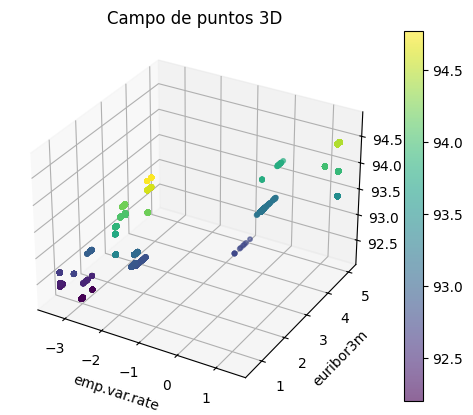

In [1055]:
# Queda claro que un factor de 0,684 explica en buena medida la influencia de ambas variables independiente en la variable dependiente.
# ahora vamos a visualizar mediante la función plot (plt) de matplotlib la nube de puntos.
X1 = Analisis_datos_mercado["emp.var.rate"]
X2 = Analisis_datos_mercado["euribor3m"]
Y = Analisis_datos_mercado["cons.price.idx"]
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X1, X2, Y,
    c=Y,              # color según valor
    cmap="viridis",   # mapa de color
    alpha=0.6,
    s=10              # tamaño pequeño → efecto más “sólido”
)

fig.colorbar(scatter)

ax.set_xlabel("emp.var.rate")
ax.set_ylabel("euribor3m")
ax.set_zlabel("cons.price.idx")

plt.title("Campo de puntos 3D")
plt.show()

a = 0.7269844218729307
b = -0.41285984117532504
intercepto = 95.01208466128283


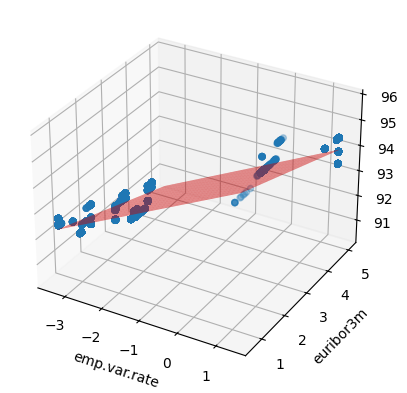

In [ ]:
##############################################################################
############################################# 2.4) Insights con CRUCE DE DATOS
##############################################################################

#Para modelos predictivos, es importante obtener el plano de regresión, lo que nos podrá dar una ecuación estadísticamente válida para predecir, ante pares de variables
# x1,x2 los posibles valores de la y.
a = modelo.params["emp.var.rate"]
b = modelo.params["euribor3m"]
c = modelo.params["const"]
print("a =", a)
print("b =", b)
print("intercepto =", c)
X1 = Analisis_datos_mercado["emp.var.rate"]
X2 = Analisis_datos_mercado["euribor3m"]
Y = Analisis_datos_mercado["cons.price.idx"]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# puntos reales
ax.scatter(X1, X2, Y, alpha=0.3)

# grid
x1_surf, x2_surf = np.meshgrid(
    np.linspace(X1.min(), X1.max(), 30),
    np.linspace(X2.min(), X2.max(), 30)
)
# ecuación del plano (usando coeficientes)
y_surf = c + a * x1_surf + b * x2_surf

# plano
ax.plot_surface(x1_surf, x2_surf, y_surf, color='red', alpha=0.5)

ax.set_xlabel("emp.var.rate")
ax.set_ylabel("euribor3m")
ax.set_zlabel("cons.price.idx")
plt.show()
# Resultados:
#a = 0.7269844218729307
#b = -0.41285984117532504
#intercepto = 95.01208466128283

# INSIGTH: Para predecir el indice de precios con una confianza del 68% aplicaremos la siguiente fórmula:
#  -------->>>>>  cons.price.idx = 95,01 + 0,727 * emp.var.rate -0,413 * euribor3m
